<a href="https://colab.research.google.com/github/samikshanimje/SmartECG-HD/blob/main/notebooks/02_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartECG-HD

## Notebook 02 — Signal Preprocessing

### Objectives

✔ Load Raw ECG

✔ Remove Noise

✔ Detect R Peaks

✔ Segment Beats

✔ Normalize Beats

✔ Save Processed Dataset

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/SmartECG-HD"

RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "datasets", "mitbih")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "processed")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
REPORT_DIR = os.path.join(PROJECT_ROOT, "reports")

for folder in [
    RAW_DATA_DIR,
    PROCESSED_DIR,
    MODEL_DIR,
    REPORT_DIR,
]:
    os.makedirs(folder, exist_ok=True)

print("Folders ready.")

Folders ready.


In [3]:
import os

os.listdir(RAW_DATA_DIR)[:10]

['100.hea', '100.dat', '100.atr']

In [4]:
!pip -q install wfdb neurokit2 scipy joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 111.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [5]:
import os
import joblib
import warnings

import wfdb
import neurokit2 as nk

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter
from scipy.signal import filtfilt

warnings.filterwarnings("ignore")

In [9]:
DATA_DIR = RAW_DATA_DIR
PROCESSED_DIR = PROCESSED_DIR

os.makedirs(PROCESSED_DIR, exist_ok=True)

In [10]:
print(DATA_DIR)

print(os.path.exists(os.path.join(DATA_DIR, "100.hea")))

print(sorted(os.listdir(DATA_DIR))[:10])

/content/drive/MyDrive/SmartECG-HD/datasets/mitbih
True
['100.atr', '100.dat', '100.hea']


In [11]:
record = wfdb.rdrecord(
    os.path.join(DATA_DIR, "100")
)

signal = record.p_signal[:, 0]

In [38]:
import sys

sys.path.append("/content/drive/MyDrive/SmartECG-HD")

from src.config import *

print(PROJECT_ROOT)
print(RAW_DATA_DIR)
print(PROCESSED_DIR)
print(BEST_MODEL_PATH)

/content/drive/MyDrive/SmartECG-HD
/content/drive/MyDrive/SmartECG-HD/datasets/mitbih
/content/drive/MyDrive/SmartECG-HD/processed
/content/drive/MyDrive/SmartECG-HD/models/best_model.keras


In [39]:
import sys

sys.path.append("/content/drive/MyDrive/SmartECG-HD")

from src.data_loader import load_record

In [21]:
import os

print(os.listdir("/content/drive/MyDrive/SmartECG-HD/src"))

['config.py', '__pycache__', 'data_loader.py']


In [22]:
!find /content/drive/MyDrive/SmartECG-HD -maxdepth 2 -type f

/content/drive/MyDrive/SmartECG-HD/src/config.py
/content/drive/MyDrive/SmartECG-HD/src/data_loader.py


In [40]:
import sys

sys.path.append("/content/drive/MyDrive/SmartECG-HD")

from src.data_loader import load_record

In [26]:
%%writefile /content/drive/MyDrive/SmartECG-HD/src/config.py

import os

# ==========================================================
# SmartECG-HD
# Global Configuration
# ==========================================================

PROJECT_ROOT = "/content/drive/MyDrive/SmartECG-HD"

RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "datasets", "mitbih")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "processed")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
REPORT_DIR = os.path.join(PROJECT_ROOT, "reports")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")
FIGURE_DIR = os.path.join(PROJECT_ROOT, "figures")

SAMPLING_RATE = 360
WINDOW_SIZE = 300
LOWCUT = 0.5
HIGHCUT = 40.0
FILTER_ORDER = 4

RANDOM_SEED = 42

BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.2

BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_model.keras")
LAST_MODEL_PATH = os.path.join(MODEL_DIR, "last_model.keras")
HISTORY_PATH = os.path.join(MODEL_DIR, "history.pkl")

BEATS_PATH = os.path.join(PROCESSED_DIR, "beats.npz")
LABELS_PATH = os.path.join(PROCESSED_DIR, "labels.npy")
METADATA_PATH = os.path.join(PROCESSED_DIR, "metadata.csv")
FEATURES_PATH = os.path.join(PROCESSED_DIR, "features.pkl")

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DIR,
    MODEL_DIR,
    REPORT_DIR,
    LOG_DIR,
    FIGURE_DIR,
]:
    os.makedirs(directory, exist_ok=True)

Writing /content/drive/MyDrive/SmartECG-HD/src/config.py


In [27]:
!head -20 /content/drive/MyDrive/SmartECG-HD/src/config.py


import os

# ==========================================================
# SmartECG-HD
# Global Configuration
# ==========================================================

PROJECT_ROOT = "/content/drive/MyDrive/SmartECG-HD"

RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "datasets", "mitbih")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "processed")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
REPORT_DIR = os.path.join(PROJECT_ROOT, "reports")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")
FIGURE_DIR = os.path.join(PROJECT_ROOT, "figures")

SAMPLING_RATE = 360
WINDOW_SIZE = 300
LOWCUT = 0.5


In [28]:
import sys
import importlib

sys.path.append("/content/drive/MyDrive/SmartECG-HD")

import src.config
importlib.reload(src.config)

from src.config import *

print(RAW_DATA_DIR)
print(BEST_MODEL_PATH)

/content/drive/MyDrive/SmartECG-HD/datasets/mitbih
/content/drive/MyDrive/SmartECG-HD/models/best_model.keras


In [33]:
%%writefile /content/drive/MyDrive/SmartECG-HD/src/preprocessing.py

import numpy as np
import neurokit2 as nk

from scipy.signal import butter, filtfilt

from src.config import (
    SAMPLING_RATE,
    LOWCUT,
    HIGHCUT,
    FILTER_ORDER,
    WINDOW_SIZE
)


def bandpass_filter(signal):
    """
    Butterworth Bandpass Filter
    """

    nyquist = 0.5 * SAMPLING_RATE

    low = LOWCUT / nyquist
    high = HIGHCUT / nyquist

    b, a = butter(
        FILTER_ORDER,
        [low, high],
        btype="band"
    )

    filtered = filtfilt(b, a, signal)

    return filtered


def normalize_signal(signal):
    """
    Z-score normalization
    """

    signal = (signal - np.mean(signal)) / np.std(signal)

    return signal


def detect_rpeaks(signal):
    """
    Detect R Peaks using NeuroKit2
    """

    _, info = nk.ecg_peaks(
        signal,
        sampling_rate=SAMPLING_RATE
    )

    return info["ECG_R_Peaks"]


def segment_beats(signal, rpeaks):
    """
    Extract 300-sample beat windows around each R Peak
    """

    half_window = WINDOW_SIZE // 2

    beats = []

    valid_peaks = []

    for peak in rpeaks:

        start = peak - half_window
        end = peak + half_window

        if start >= 0 and end < len(signal):

            beats.append(signal[start:end])

            valid_peaks.append(peak)

    return np.array(beats), np.array(valid_peaks)

Overwriting /content/drive/MyDrive/SmartECG-HD/src/preprocessing.py


In [34]:
import sys
import importlib

sys.path.append("/content/drive/MyDrive/SmartECG-HD")

import src.preprocessing
importlib.reload(src.preprocessing)

from src.preprocessing import *

In [35]:
from src.data_loader import load_record

record, annotation = load_record("100")

signal = record.p_signal[:, 0]

filtered_signal = bandpass_filter(signal)

normalized_signal = normalize_signal(filtered_signal)

rpeaks = detect_rpeaks(normalized_signal)

beats, valid_peaks = segment_beats(
    normalized_signal,
    rpeaks
)

In [32]:
filtered_signal = bandpass_filter(signal)

print(filtered_signal.shape)

(650000,)


In [36]:
print("Signal Shape :", signal.shape)
print("Filtered Shape :", filtered_signal.shape)
print("Normalized Shape :", normalized_signal.shape)
print("Detected R Peaks :", len(rpeaks))
print("Extracted Beats :", beats.shape)

Signal Shape : (650000,)
Filtered Shape : (650000,)
Normalized Shape : (650000,)
Detected R Peaks : 2270
Extracted Beats : (2270, 300)


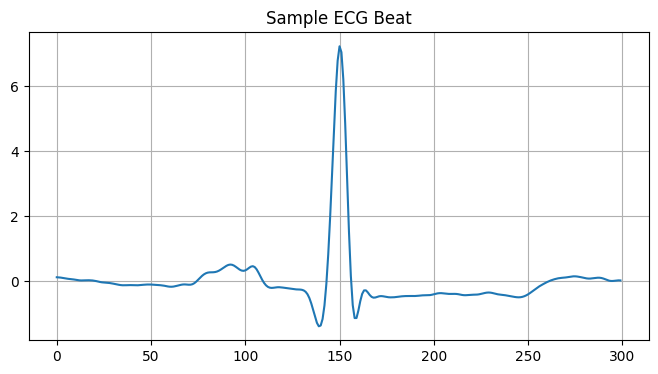

In [37]:
plt.figure(figsize=(8,4))

plt.plot(beats[100])

plt.title("Sample ECG Beat")

plt.grid()

plt.show()

In [41]:
%%writefile /content/drive/MyDrive/SmartECG-HD/src/save_utils.py

import numpy as np
import pandas as pd
import joblib

from src.config import (
    BEATS_PATH,
    LABELS_PATH,
    METADATA_PATH
)


def save_processed_dataset(beats, labels, metadata):

    np.savez_compressed(
        BEATS_PATH,
        beats=beats
    )

    np.save(
        LABELS_PATH,
        labels
    )

    metadata.to_csv(
        METADATA_PATH,
        index=False
    )

    print("✅ Processed dataset saved successfully.")

Writing /content/drive/MyDrive/SmartECG-HD/src/save_utils.py


In [42]:
import sys
import importlib

sys.path.append("/content/drive/MyDrive/SmartECG-HD")

import src.save_utils
importlib.reload(src.save_utils)

from src.save_utils import save_processed_dataset

In [43]:
metadata = pd.DataFrame({

    "record": "100",

    "rpeak": valid_peaks

})

In [46]:
%%writefile /content/drive/MyDrive/SmartECG-HD/src/label_generator.py

import numpy as np

# AAMI Mapping
AAMI_MAP = {
    'N': 'N',
    'L': 'N',
    'R': 'N',
    'e': 'N',
    'j': 'N',

    'A': 'S',
    'a': 'S',
    'J': 'S',
    'S': 'S',

    'V': 'V',
    'E': 'V',

    'F': 'F',

    '/': 'Q',
    'f': 'Q',
    'Q': 'Q'
}


def generate_labels(annotation, valid_peaks):

    labels = []

    ann_samples = annotation.sample
    ann_symbols = annotation.symbol

    for peak in valid_peaks:

        idx = np.argmin(np.abs(ann_samples - peak))

        symbol = ann_symbols[idx]

        label = AAMI_MAP.get(symbol, "Q")

        labels.append(label)

    return np.array(labels)

Writing /content/drive/MyDrive/SmartECG-HD/src/label_generator.py


In [47]:
import sys
import importlib

sys.path.append("/content/drive/MyDrive/SmartECG-HD")

import src.label_generator
importlib.reload(src.label_generator)

from src.label_generator import generate_labels

In [48]:
labels = generate_labels(
    annotation,
    valid_peaks
)

print(labels[:20])

['N' 'N' 'N' 'N' 'N' 'N' 'S' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N'
 'N' 'N']


In [49]:
import pandas as pd

pd.Series(labels).value_counts()

,count
N,2237
S,33


In [50]:
metadata = pd.DataFrame({
    "record": "100",
    "rpeak": valid_peaks,
    "label": labels
})

In [51]:
save_processed_dataset(
    beats,
    labels,
    metadata
)

✅ Processed dataset saved successfully.


In [52]:
print(BEATS_PATH)
print(LABELS_PATH)
print(METADATA_PATH)

/content/drive/MyDrive/SmartECG-HD/processed/beats.npz
/content/drive/MyDrive/SmartECG-HD/processed/labels.npy
/content/drive/MyDrive/SmartECG-HD/processed/metadata.csv


In [53]:
pd.Series(labels).value_counts()

,count
N,2237
S,33


In [54]:
%%writefile /content/drive/MyDrive/SmartECG-HD/src/dataset_builder.py

import numpy as np
import pandas as pd

from src.data_loader import load_record
from src.preprocessing import (
    bandpass_filter,
    normalize_signal,
    detect_rpeaks,
    segment_beats,
)
from src.label_generator import generate_labels


MITBIH_RECORDS = [
    "100","101","102","103","104","105","106","107",
    "108","109","111","112","113","114","115","116",
    "117","118","119","121","122","123","124","200",
    "201","202","203","205","207","208","209","210",
    "212","213","214","215","217","219","220","221",
    "222","223","228","230","231","232","233","234"
]


def build_dataset():

    all_beats = []
    all_labels = []
    metadata = []

    for record_id in MITBIH_RECORDS:

        print(f"Processing {record_id}...")

        record, annotation = load_record(record_id)

        signal = record.p_signal[:, 0]

        signal = bandpass_filter(signal)

        signal = normalize_signal(signal)

        rpeaks = detect_rpeaks(signal)

        beats, valid_peaks = segment_beats(signal, rpeaks)

        labels = generate_labels(annotation, valid_peaks)

        all_beats.extend(beats)
        all_labels.extend(labels)

        for peak, label in zip(valid_peaks, labels):

            metadata.append({
                "record": record_id,
                "rpeak": peak,
                "label": label
            })

    return (
        np.array(all_beats),
        np.array(all_labels),
        pd.DataFrame(metadata)
    )

Writing /content/drive/MyDrive/SmartECG-HD/src/dataset_builder.py


In [55]:
import sys
import importlib

sys.path.append("/content/drive/MyDrive/SmartECG-HD")

import src.dataset_builder
importlib.reload(src.dataset_builder)

from src.dataset_builder import build_dataset

In [57]:
import wfdb
import os

from src.dataset_builder import MITBIH_RECORDS
from src.config import RAW_DATA_DIR

print("Downloading all MIT-BIH records...")

wfdb.dl_database(
    "mitdb",
    dl_dir=RAW_DATA_DIR,
    records=MITBIH_RECORDS
)

print("✅ Download complete!")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

KeyboardInterrupt: 

In [58]:
import os

print(len(os.listdir(RAW_DATA_DIR)))

77


In [59]:
import wfdb

from src.dataset_builder import MITBIH_RECORDS
from src.config import RAW_DATA_DIR

wfdb.dl_database(
    "mitdb",
    dl_dir=RAW_DATA_DIR,
    records=MITBIH_RECORDS
)

print("All records downloaded.")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [60]:
%%writefile /content/drive/MyDrive/SmartECG-HD/src/dataset_builder.py

import os
import numpy as np
import pandas as pd

from src.data_loader import load_record
from src.preprocessing import (
    bandpass_filter,
    normalize_signal,
    detect_rpeaks,
    segment_beats
)

from src.label_generator import generate_labels
from src.config import (
    BEATS_PATH,
    LABELS_PATH,
    METADATA_PATH
)

MITBIH_RECORDS = [
    "100","101","102","103","104","105","106","107",
    "108","109","111","112","113","114","115","116",
    "117","118","119","121","122","123","124","200",
    "201","202","203","205","207","208","209","210",
    "212","213","214","215","217","219","220","221",
    "222","223","228","230","231","232","233","234"
]


def build_dataset():

    all_beats=[]
    all_labels=[]
    metadata=[]

    for record_id in MITBIH_RECORDS:

        print("Processing",record_id)

        record,annotation=load_record(record_id)

        signal=record.p_signal[:,0]

        signal=bandpass_filter(signal)

        signal=normalize_signal(signal)

        rpeaks=detect_rpeaks(signal)

        beats,valid_peaks=segment_beats(signal,rpeaks)

        labels=generate_labels(annotation,valid_peaks)

        all_beats.extend(beats)

        all_labels.extend(labels)

        for p,l in zip(valid_peaks,labels):

            metadata.append({
                "record":record_id,
                "rpeak":p,
                "label":l
            })

        # SAVE AFTER EVERY RECORD
        np.savez_compressed(
            BEATS_PATH,
            beats=np.array(all_beats)
        )

        np.save(
            LABELS_PATH,
            np.array(all_labels)
        )

        pd.DataFrame(metadata).to_csv(
            METADATA_PATH,
            index=False
        )

        print("Saved.")

    return (
        np.array(all_beats),
        np.array(all_labels),
        pd.DataFrame(metadata)
    )

Overwriting /content/drive/MyDrive/SmartECG-HD/src/dataset_builder.py


In [61]:
import importlib
import src.dataset_builder

importlib.reload(src.dataset_builder)

from src.dataset_builder import build_dataset

In [62]:
beats,labels,metadata=build_dataset()

Processing 100
Saved.
Processing 101
Saved.
Processing 102
Saved.
Processing 103
Saved.
Processing 104
Saved.
Processing 105
Saved.
Processing 106
Saved.
Processing 107
Saved.
Processing 108
Saved.
Processing 109
Saved.
Processing 111
Saved.
Processing 112
Saved.
Processing 113
Saved.
Processing 114
Saved.
Processing 115
Saved.
Processing 116
Saved.
Processing 117
Saved.
Processing 118
Saved.
Processing 119
Saved.
Processing 121
Saved.
Processing 122
Saved.
Processing 123
Saved.
Processing 124
Saved.
Processing 200
Saved.
Processing 201
Saved.
Processing 202
Saved.
Processing 203
Saved.
Processing 205
Saved.
Processing 207
Saved.
Processing 208
Saved.
Processing 209
Saved.
Processing 210
Saved.
Processing 212
Saved.
Processing 213
Saved.
Processing 214
Saved.
Processing 215
Saved.
Processing 217
Saved.
Processing 219
Saved.
Processing 220
Saved.
Processing 221
Saved.
Processing 222
Saved.
Processing 223
Saved.
Processing 228
Saved.
Processing 230
Saved.
Processing 231
Saved.
Processing

In [63]:
print(beats.shape)

(109380, 300)


In [64]:
pd.Series(labels).value_counts()

,count
N,90453
Q,8381
V,7044
S,2703
F,799


In [65]:
%%writefile /content/drive/MyDrive/SmartECG-HD/src/feature_engineering.py

import neurokit2 as nk
import numpy as np

from src.config import SAMPLING_RATE


def extract_hrv_features(signal):

    _, info = nk.ecg_peaks(
        signal,
        sampling_rate=SAMPLING_RATE
    )

    hrv = nk.hrv_time(
        info,
        sampling_rate=SAMPLING_RATE,
        show=False
    )

    return hrv

Writing /content/drive/MyDrive/SmartECG-HD/src/feature_engineering.py


In [66]:
import sys
import importlib

sys.path.append("/content/drive/MyDrive/SmartECG-HD")

import src.feature_engineering
importlib.reload(src.feature_engineering)

from src.feature_engineering import extract_hrv_features

In [67]:
record, annotation = load_record("100")

signal = record.p_signal[:,0]

features = extract_hrv_features(signal)

features.head()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN
0,794.620656,49.247174,19.628562,42.805708,18.285175,44.739633,16.126545,46.488604,64.240367,64.254505,...,50.0,0.766608,766.666667,827.777778,10.176211,48.546256,475.0,1191.666667,10.809524,0.0
